In [2]:
import os
import yaml
import geopandas as gpd
import osmnx as ox
from shapely.geometry import box
import matplotlib.pyplot as plt

# 1. Config 파일 로드 (예외 처리 포함)
config_path = '../config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
# 2. Config 하이퍼파라미터 변수 할당
TARGET_REGION = config['spatial']['target_region']        # "Gwangju, South Korea"
BASE_CRS = config['spatial']['base_crs']                  # "EPSG:4326"
PROJ_CRS = config['spatial']['projected_crs']             # "EPSG:5179"
GRID_SIZE = config['spatial']['grid_size_meters']         # 10 (m)
print(f"✅ 설정 로드 완료: {TARGET_REGION} | {PROJ_CRS} | {GRID_SIZE}m Grid")

✅ 설정 로드 완료: Gwangju, South Korea | EPSG:5179 | 10m Grid


In [3]:
# 1. 광주광역시의 보행자 전용 도로망 네트워크 추출
# 다운로드에 시간이 약간 소요될 수 있습니다.
print(f"[{TARGET_REGION}] 도로망 다운로드 중...")
graph = ox.graph_from_place(TARGET_REGION, network_type="walk")

# 2. Graph 구조에서 엣지(Edge - 선형 도로 데이터)만 추출하여 GeoDataFrame으로 변환
nodes, edges = ox.graph_to_gdfs(graph)

# 3. [Rule 1 준수]: 다운로드된 원본 위경도 좌표계(4326)를 미터 단위 계산이 가능한 5179로 재투영(.to_crs)
edges_proj = edges.to_crs(PROJ_CRS)

print(f"✅ 엣지 추출 완료! 총 {len(edges_proj)} 개의 도로 구간이 로드(투영)되었습니다.")


[Gwangju, South Korea] 도로망 다운로드 중...
✅ 엣지 추출 완료! 총 139012 개의 도로 구간이 로드(투영)되었습니다.


In [ ]:
import pandas as pd

# 1. 각 도로 엣지에 30m 버퍼 적용하여 보행 접근 가능 범위(Polygon) 생성
print("30m 보행 면적 마스킹(Buffer)...")
walking_areas = edges_proj.geometry.buffer(10)
# 2. GeoDataFrame 씌우기
gdf_walkable = gpd.GeoDataFrame(geometry=walking_areas, crs=PROJ_CRS).reset_index(drop=True)

print(f"✅ 도화지 생성 완료! 면적: {gdf_walkable.area[0]:.2f} 제곱미터")

30m 보행 면적 마스킹(Buffer)...
✅ 도화지 생성 완료! 면적: 6239.23 제곱미터


In [6]:
import numpy as np
from shapely.geometry import box

print("10m 정방형 격자망(Grid) 배열 생성 중...")
# 1. Bounding Box 추출 (원본 도로망 기준)
minx, miny, maxx, maxy = edges_proj.total_bounds
# 버퍼 30m를 감안해 앞뒤로 50m씩 넉넉하게 확장
minx-=50; miny-=50; maxx+=50; maxy+=50

x_coords = np.arange(minx, maxx, GRID_SIZE)
y_coords = np.arange(miny, maxy, GRID_SIZE)

polygons = []
for x in x_coords:
    for y in y_coords:
        polygons.append(box(x, y, x + GRID_SIZE, y + GRID_SIZE))

grid_gdf = gpd.GeoDataFrame(geometry=polygons, crs=PROJ_CRS)
print(f"초기 생성된 전체 격자 수: {len(grid_gdf)} 개")

# 2. 고속 공간 조인 (sindex가 파편화된 다중 바운딩 박스를 1초 만에 쳐냄)
print("위치 타겟팅(Spatial Join) 중...")
grid_masked = gpd.sjoin(grid_gdf, gdf_walkable, predicate='intersects')

# 3. 여러 도로 파편에 동시에 겹쳐서 중복 생성된 격자 타일들을 하나만 남기고 전부 제거
grid_masked = grid_masked[~grid_masked.index.duplicated(keep='first')].copy()

# 4. 깔끔하게 정리
grid_masked = grid_masked.drop(columns=['index_right']).reset_index(drop=True)
grid_masked['grid_id'] = grid_masked.index.astype(str)

print(f"✅ 마스킹 최적화 완료! 실제 쓰일 격자 수: {len(grid_masked)} 개")


10m 정방형 격자망(Grid) 배열 생성 중...
초기 생성된 전체 격자 수: 7570205 개
위치 타겟팅(Spatial Join) 중...
✅ 마스킹 최적화 완료! 실제 쓰일 격자 수: 2352275 개


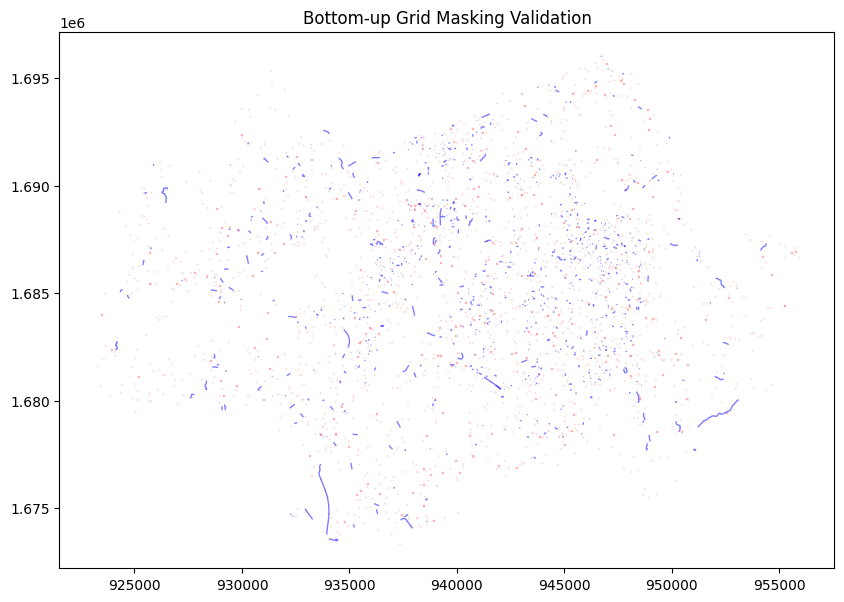

✅ 파이프라인 중간 결과물 저장 완료! (포맷: GeoPackage) -> /home/jihwan38/machine-learning-practice/data/processed/gwangju_10m_grid_v1.gpkg


In [8]:
import os

# 1. Bounding Box 시각적 검증
fig, ax = plt.subplots(figsize=(10, 10))
edges_proj.sample(min(1000, len(edges_proj))).plot(ax=ax, linewidth=1, edgecolor='blue', alpha=0.5, label='Walk Edges')
grid_masked.sample(min(5000, len(grid_masked))).plot(ax=ax, facecolor='none', edgecolor='red', alpha=0.3, label='10m Grid')
plt.title("Bottom-up Grid Masking Validation")
plt.show()

# 2. 유령 경로 방지: 현재 위치(notebooks)에서 두 칸 뒤(../../)인 진짜 프로젝트 루트 경로를 추적
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
processed_dir = os.path.join(project_root, "data", "processed")

# 혹시 몰라서 폴더가 없다면 자동으로 만들어주는 안전장치
os.makedirs(processed_dir, exist_ok=True)

# 3. GeoPackage 형식으로 안전하게 굽기
output_path = os.path.join(processed_dir, 'gwangju_10m_grid_v1.gpkg')
grid_masked.to_file(output_path, driver='GPKG', layer='grid_10m')

print(f"✅ 파이프라인 중간 결과물 저장 완료! (포맷: GeoPackage) -> {output_path}")


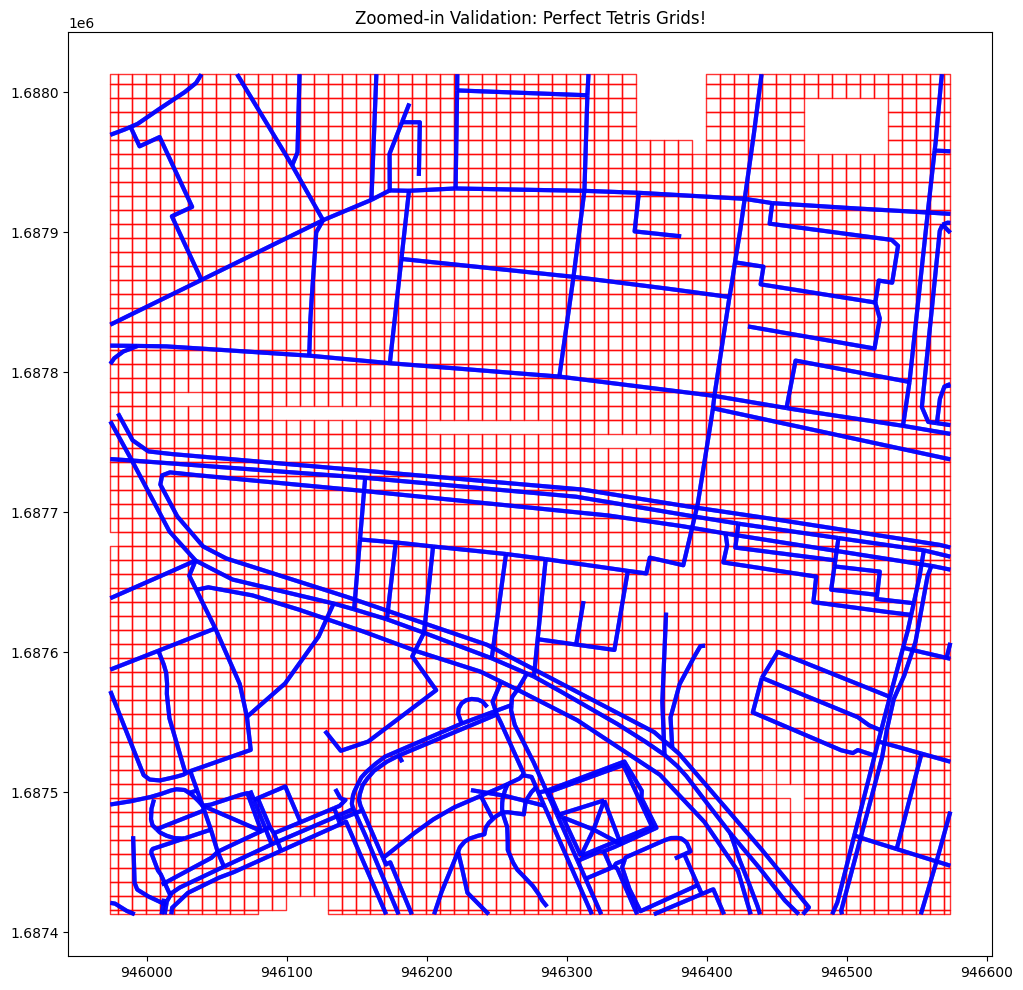

In [9]:
# 무작위로 기준점 하나 잡기 (도로 리스트의 1000번째 도로 기준)
sample_x = edges_proj.geometry.iloc[1000].centroid.x
sample_y = edges_proj.geometry.iloc[1000].centroid.y

# 기준점에서 상하좌우 300m 크기의 뷰파인더(박스) 만들기
from shapely.geometry import box
view_box = box(sample_x - 300, sample_y - 300, sample_x + 300, sample_y + 300)

# 전체 데이터에서 뷰파인더 에 들어오는 부분만 가위로 싹둑 자르기 (Clip)
edges_zoom = gpd.clip(edges_proj, view_box)
grid_zoom = gpd.clip(grid_masked, view_box)

# 줌-인 상태에서는 전체 데이터를 다 그려도 안 터집니다!
fig, ax = plt.subplots(figsize=(12, 12))
edges_zoom.plot(ax=ax, linewidth=3, color='blue', alpha=0.8, label='Walking Path')
grid_zoom.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1, alpha=0.8, label='10m Grid')

plt.title("Zoomed-in Validation: Perfect Tetris Grids!")
plt.show()


In [10]:
from shapely.geometry import Point

# 1. 줌-인 했던 중심점 (EPSG:5179 미터 좌표계)
center_point = Point(sample_x, sample_y)

# 2. 이걸 지도 앱에서 쓸 수 있는 일반 위경도(EPSG:4326)로 역투영 변환
point_4326 = gpd.GeoSeries([center_point], crs=PROJ_CRS).to_crs(BASE_CRS).iloc[0]

lat = point_4326.y # 위도
lon = point_4326.x # 경도

print(f"🗺️ 카카오/네이버 맵 검색 좌표 (지도에 복붙해 보세요!)")
print(f"{lat:.6f}, {lon:.6f}")


🗺️ 카카오/네이버 맵 검색 좌표 (지도에 복붙해 보세요!)
35.183278, 126.909917
